# 🖼️ 03-深度学习 · 模型笔记 2：卷积神经网络 CNN（手写全流程）

> CNN 三件套：**卷积（局部连接+权共享）→ 激活 → 池化（降采样）**。本笔记手写卷积/池化**前向+反向**、垂范 im2col，并训练一个微型 CNN。
> 本 notebook 要求：**卷积、池化、全连接全部手写 numpy**（含反向传播与训练）；末尾用同结构 PyTorch 网络对照验证。

**运行环境**：Python 3.8+，依赖 numpy（对照部分可选 torch）。

**直觉：卷积 = 模板匹配**。卷积核就是一张小模板（边缘、纹理、色块…），滑动窗口在输入上逐位置与该模板做内积打分——越相似得分越高。整张图被核扫过一遍，每个位置得到一个分数，即形成**激活图（热力图）**：分数代表"该处与模板的匹配度"。多个核 = 多张模板，堆叠成通道；训练 CNN 就是学习"该用哪些模板"。


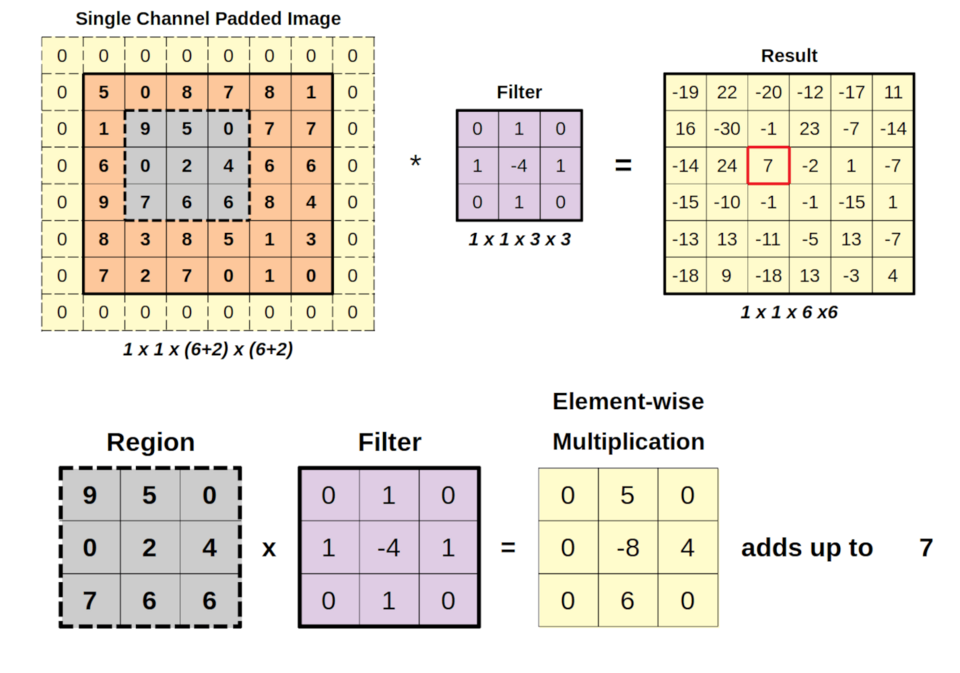

> 📷 卷积计算过程：卷积核滑动+逐位置点积得到特征图
> *图源：Wikimedia Commons（开放授权）*


## §1 卷积的数学定义

**互相关（实际工程用的「卷积」）**：对单通道输入 $X \in \mathbb{R}^{H \times W}$、卷积核 $K \in \mathbb{R}^{k_h \times k_w}$：

$$Y[i, j] = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} X[i+m, \, j+n] \cdot K[m, n] + b$$

（信号处理里的卷积要翻转核；DL 的 conv 实际是 cross-correlation，只是习惯叫卷积。）

**多通道（C_in → C_out）**：每个输出通道有自己的核张量，跨输入通道求和：

$$Y[c_o, i, j] = \sum_{c_i} \sum_{m, n} X[c_i, i+m, j+n] \cdot K[c_o, c_i, m, n] + b[c_o]$$

**输出尺寸公式**（padding $P$、stride $S$）：

$$H_{out} = \left\lfloor \frac{H + 2P - k_h}{S} \right\rfloor + 1, \qquad W_{out} = \left\lfloor \frac{W + 2P - k_w}{S} \right\rfloor + 1$$

**参数量**：$C_{out} \times (C_{in} \times k_h \times k_w + 1)$——与输入尺寸**无关**（这是 CNN 能吃大图的关键）。

In [ ]:
import numpy as np

def conv2d_forward(X, W, b=None, stride=1, pad=0):
    """
    手写 2D 多通道卷积（循环版，教学清晰）
    X: [C_in, H, W]   W: [C_out, C_in, kh, kw]   b: [C_out] 或 None
    返回 Y: [C_out, H_out, W_out]
    """
    C_in, H, Wd = X.shape          # 注意：宽度不能用 W 命名（会覆盖参数 W=卷积核）
    C_out, _, kh, kw = W.shape
    Xp = np.pad(X, ((0, 0), (pad, pad), (pad, pad)))     # 零填充
    H_out = (H + 2 * pad - kh) // stride + 1
    W_out = (Wd + 2 * pad - kw) // stride + 1
    Y = np.zeros((C_out, H_out, W_out))
    for co in range(C_out):
        for i in range(H_out):
            for j in range(W_out):
                h0, w0 = i * stride, j * stride
                patch = Xp[:, h0:h0 + kh, w0:w0 + kw]        # [C_in, kh, kw]
                Y[co, i, j] = (patch * W[co]).sum()          # 逐元素乘加
                if b is not None:
                    Y[co, i, j] += b[co]
    return Y

# 示例 1：边缘检测（Sobel 风格）——手写小图验证卷积正确性
X1 = np.array([
    [0., 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]], dtype=float)
sobel = np.array([[1., 0, -1], [2, 0, -2], [1, 0, -1]])   # 竖向边缘核
Y1 = conv2d_forward(X1[None], sobel[None, None], stride=1, pad=1)
print('5x5 方块 → Sober 卷积输出（中间特征图）:')
print(np.round(Y1[0], 2))
print('（左右边缘响应大、中间平坦→0，验证卷积做边缘检测）')

print('\n尺寸公式验证: H_in=5, k=3, P=1, S=1 → H_out =', (5 + 2 - 3) // 1 + 1, '✓')
print('H_in=5, k=3, P=0, S=2 → H_out =', (5 - 3) // 2 + 1, '（stride 2 下采样）✓')

## §2 im2col：把卷积变成矩阵乘法（工程必考）

卷积的滑动窗等价于：

1. **im2col**：把每个感受野窗口摊平成一行 → $X_{col} \in \mathbb{R}^{(H_{out} W_{out}) \times (C_{in} k_h k_w)}$
2. **GEMM**：$Y_{col} = X_{col} W_{col}^{\top}$（$W_{col} \in \mathbb{R}^{C_{out} \times (C_{in} k_h k_w)}$）
3. **col2im**：把结果 reshape 回 $[C_{out}, H_{out}, W_{out}]$

**代价**：内存放大 $k_h k_w$ 倍（重排冗余数据），换来 BLAS 高速矩阵乘 + GPU 友好——cuDNN 的经典路径。

公式视角（一个位置一行）：

$$\underbrace{Y_{col}[p, :]}_{1 \times C_{out}} = \underbrace{X_{col}[p, :]}_{1 \times (C_{in}k_hk_w)} \; \underbrace{W_{col}^{\top}}_{(C_{in}k_hk_w) \times C_{out}}$$

In [ ]:
def im2col(X, kh, kw, stride=1, pad=0):
    """X: [C_in, H, W] → col: [(H_out*W_out), C_in*kh*kw]"""
    C_in, H, W = X.shape
    Xp = np.pad(X, ((0, 0), (pad, pad), (pad, pad)))
    H_out = (H + 2 * pad - kh) // stride + 1
    W_out = (W + 2 * pad - kw) // stride + 1
    cols = []
    for i in range(H_out):
        for j in range(W_out):
            patch = Xp[:, i * stride:i * stride + kh, j * stride:j * stride + kw]
            cols.append(patch.reshape(-1))
    return np.array(cols)                                   # [H_out*W_out, C_in*kh*kw]

def conv2d_im2col(X, W, b=None, stride=1, pad=0):
    C_out, C_in, kh, kw = W.shape
    Xcol = im2col(X, kh, kw, stride, pad)                    # GEMM 前置重排
    Wcol = W.reshape(C_out, -1)                              # [C_out, C_in*kh*kw]
    Ycol = Xcol @ Wcol.T                                     # 矩阵乘法（中间量）
    if b is not None:
        Ycol += b
    H_out = (X.shape[1] + 2 * pad - kh) // stride + 1
    W_out = (X.shape[2] + 2 * pad - kw) // stride + 1
    return Ycol.T.reshape(C_out, H_out, W_out)               # col2im reshape

# 随机验证：两种实现完全一致
rng = np.random.default_rng(0)
Xr = rng.normal(0, 1, (3, 8, 8))          # 3 通道
Wr = rng.normal(0, 0.1, (4, 3, 3, 3))     # 4 个 3x3 核
br = rng.normal(0, 0.1, 4)
Yo = conv2d_forward(Xr, Wr, br, stride=2, pad=1)
Yi = conv2d_im2col(Xr, Wr, br, stride=2, pad=1)
print('循环版输出形状:', Yo.shape, ' im2col 版输出形状:', Yi.shape)
print('两种实现完全一致:', np.allclose(Yo, Yi, atol=1e-10))
print('im2col 矩阵形状 [窗口数, 展平核] =', im2col(Xr, 3, 3, stride=2, pad=1).shape,
      '（8x8 输入 S=2 P=1 → 4x4 输出 = 16 个窗口）')

In [ ]:
def max_pool_forward(X, size=2, stride=2):
    """X: [C, H, W] → 最大池化（中间输出含 argmax 索引，供反向用）"""
    C, H, W = X.shape
    H_out = (H - size) // stride + 1
    W_out = (W - size) // stride + 1
    Y = np.zeros((C, H_out, W_out))
    argmax = np.zeros((C, H_out, W_out, 2), dtype=int)   # 记录每个窗口最大值位置
    for c in range(C):
        for i in range(H_out):
            for j in range(W_out):
                win = X[c, i * stride:i * stride + size, j * stride:j * stride + size]
                m = np.unravel_index(np.argmax(win), win.shape)
                Y[c, i, j] = win[m]
                argmax[c, i, j] = (i * stride + m[0], j * stride + m[1])
    return Y, argmax

# 示例：2x2 最大池化（下采样 4 倍）
Xp1 = np.array([[[1., 3, 2, 4],
                 [5, 6, 8, 7],
                 [9, 1, 2, 0],
                 [4, 3, 5, 6]]])
Yp, am = max_pool_forward(Xp1)
print('2x2 最大池化输出:')
print(Yp[0])
print('期望坐标 (0,0)->6? 不: 窗口[[1,3],[5,6]] 最大=6 ✓; 期望整个输出 [[6,8],[9,6]]')
print('实际:', Yp[0].astype(int).tolist())
print('尺寸: 4x4 →', Yp.shape[-2:], '（每池化一次尺寸减半；通道数不变）')

### §2.5 卷积反向传播：三条梯度公式（BP 核心）

前向 $Y = X*W + b$，已知上游梯度 $\partial L/\partial Y$（记 dY），BP 回传三条梯度：

- **dW** = 输入 $X$ 与上游梯度 $dY$ 的**互相关**：$dW[m,n] = \sum_{p,q} dY[p,q]\cdot X[p+m,\, q+n]$——哪个窗口激活了核的哪个位置，就把梯度累加给谁；
- **db** = 通道级梯度求和：$db = \sum_{p,q} dY[p,q]$；
- **dX** = 把 $dY$ **补 padding** 后与**翻转（上下左右）核**做卷积：$dX[i,j] = \sum_{p,q} dY[p,q]\cdot W[i-p,\, j-q]$——梯度"卷积回去"发还给每个输入像素。

**池化反向**：max pool 前向时把每个窗口的 argmax 位置存进返回的 argmax 数组（见上一节），反向时**只把梯度回传给最大值像素**，窗口内其余位置梯度为 0；avg pool 则把梯度均分给窗口内所有像素。

**唯一校验标准 = 数值梯度**：用中心差分 $\dfrac{f(x+\epsilon)-f(x-\epsilon)}{2\epsilon}$（$\epsilon=10^{-6}$）与解析梯度逐元素比对（rtol=1e-3），这是检验手写 BP 是否正确的金标准。


In [ ]:
def conv2d_forward1(X, W, b=0.0):
    """单通道、无 padding、stride=1 的最简卷积前向：X [H, W], W [kh, kw] → Y [H-kh+1, W-kw+1]"""
    H, Wd = X.shape
    kh, kw = W.shape
    Y = np.zeros((H - kh + 1, Wd - kw + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + kh, j:j + kw] * W).sum() + b
    return Y

def conv2d_backward(X, W, dY):
    """单通道卷积反向：回传三条梯度
    dW = X 与 dY 的互相关；db = Σ dY；dX = dY 补 padding 后与翻转核卷积"""
    H, Wd = X.shape
    kh, kw = W.shape
    dW = np.zeros_like(W)
    db = dY.sum()
    for p in range(dY.shape[0]):                 # dW[m,n] = Σ_{p,q} dY[p,q]·X[p+m, q+n]
        for q in range(dY.shape[1]):
            dW += dY[p, q] * X[p:p + kh, q:q + kw]
    dX = np.zeros((H, Wd))
    Ypad = np.pad(dY, ((kh - 1, kh - 1), (kw - 1, kw - 1)))   # dY 补 padding
    Wf = W[::-1, ::-1]                                          # 翻转核
    for i in range(H):
        for j in range(Wd):                                     # 与翻转核卷积 → dX
            dX[i, j] = (Ypad[i:i + kh, j:j + kw] * Wf).sum()
    return dX, dW, db

# ========== 中心差分数值梯度检查：解析 vs 数值 ==========
rng = np.random.default_rng(42)
X0 = rng.normal(0, 1, (3, 3))      # 随机 3x3 输入
W0 = rng.normal(0, 0.5, (2, 2))    # 2x2 核 → 输出 2x2
dY0 = rng.normal(0, 1, (2, 2))     # 假定的上游梯度
eps = 1e-6

def loss(X, W):
    return (conv2d_forward1(X, W, 0.0) * dY0).sum()    # L = Σ dY·conv(X, W)

dW_num = np.zeros_like(W0)
dX_num = np.zeros_like(X0)
for m in range(W0.shape[0]):        # df/dW 中心差分
    for n in range(W0.shape[1]):
        Wp = W0.copy(); Wp[m, n] += eps
        Wm = W0.copy(); Wm[m, n] -= eps
        dW_num[m, n] = (loss(X0, Wp) - loss(X0, Wm)) / (2 * eps)
for i in range(X0.shape[0]):        # df/dX 中心差分
    for j in range(X0.shape[1]):
        Xp = X0.copy(); Xp[i, j] += eps
        Xm = X0.copy(); Xm[i, j] -= eps
        dX_num[i, j] = (loss(Xp, W0) - loss(Xm, W0)) / (2 * eps)

dX_an, dW_an, db_an = conv2d_backward(X0, W0, dY0)
err_dW = np.abs(dW_an - dW_num).max()
err_dX = np.abs(dX_an - dX_num).max()
ok = np.allclose(dW_an, dW_num, rtol=1e-3, atol=1e-6) and np.allclose(dX_an, dX_num, rtol=1e-3, atol=1e-6)
print('dW 最大误差 = %.3e   dX 最大误差 = %.3e   db = %.4f' % (err_dW, err_dX, db_an))
print('解析 dW =', np.round(dW_an, 4).tolist())
print('数值 dW =', np.round(dW_num, 4).tolist())
print('数值梯度检查:', 'PASS ✓（解析梯度与中心差分一致）' if ok else 'FAIL ✗')


## §3 手写微型 CNN（卷积+池化+全连接）跑通分类

搭一个 LeNet 前向：卷积(1→4, 3x3) → ReLU → 池化 → 卷积(4→8, 3x3) → ReLU → 池化(→展平) → 全连接 → softmax。

**感受野公式**（第 $l$ 层卷积核 $k_l$、步长 $s_l$）：

$$r_0 = 1, \quad r_{l} = r_{l-1} + (k_l - 1) \prod_{j<l} s_j$$

深层网络靠堆叠卷积把感受野扩大——不需要大核也能看全局。

In [ ]:
def relu(A):
    return np.maximum(A, 0)

def softmax_rows(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)

def conv2d_batch(X, W, b, stride=1, pad=0):
    """多通道卷积（batch 版）：X [N, C_in, H, W] → Y [N, C_out, H_out, W_out]
    窗口级向量化：H_out×W_out 个位置循环，每个位置一次 tensordot 算完 N×C_out"""
    N, C_in, H, Wd = X.shape
    C_out, _, kh, kw = W.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    H_out = (H + 2 * pad - kh) // stride + 1
    W_out = (Wd + 2 * pad - kw) // stride + 1
    Y = np.zeros((N, C_out, H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = Xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]  # [N, C_in, kh, kw]
            Y[:, :, i, j] = np.tensordot(patch, W, axes=([1, 2, 3], [1, 2, 3])) + b
    return Y

def max_pool_batch(X, size=2, stride=2):
    """最大池化（batch 版）：X [N, C, H, W] → (Y [N, C, H_out, W_out], 每窗口 argmax 位置)"""
    N, C, H, Wd = X.shape
    H_out = (H - size) // stride + 1
    W_out = (Wd - size) // stride + 1
    Y = np.zeros((N, C, H_out, W_out))
    pos = np.zeros((N, C, H_out, W_out, 2), dtype=int)
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    win = X[n, c, i * stride:i * stride + size, j * stride:j * stride + size]
                    m = np.unravel_index(np.argmax(win), win.shape)
                    Y[n, c, i, j] = win[m]
                    pos[n, c, i, j] = (i * stride + m[0], j * stride + m[1])
    return Y, pos

class TinyCNN:
    """微型 CNN：conv(1→4) → relu → pool → conv(4→8) → relu → pool → fc → softmax
    固定输入 8x8（fc 维度写死，不再动态重建）：
        conv1(P=1,S=1) 保持 8x8 → pool 减半 4x4 → conv2 保持 4x4 → pool 减半 2x2
        → 展平维度 = 8*2*2 = 32，fc 在 __init__ 里写死为 (32, n_classes)
    """
    def __init__(self, seed=0, n_classes=10):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.2, (4, 1, 3, 3)); self.b1 = np.zeros(4)
        self.W2 = rng.normal(0, 0.2, (8, 4, 3, 3)); self.b2 = np.zeros(8)
        self.fc = rng.normal(0, 0.1, (8 * 2 * 2, n_classes))   # 8x8 输入 → 展平 32，与输入严格对应
        self.fcb = np.zeros(n_classes)

    def forward(self, X):
        """X: [N, 1, 8, 8] → probs [N, n_classes]（缓存中间量供反向传播使用）"""
        self.X = X
        self.a1 = relu(conv2d_batch(X, self.W1, self.b1, stride=1, pad=1))         # N,4,8,8
        self.p1, self.pos1 = max_pool_batch(self.a1, 2, 2)                         # N,4,4,4
        self.a2 = relu(conv2d_batch(self.p1, self.W2, self.b2, stride=1, pad=1))  # N,8,4,4
        self.p2, self.pos2 = max_pool_batch(self.a2, 2, 2)                         # N,8,2,2
        self.flat = self.p2.reshape(self.p2.shape[0], -1)                          # N,32（与 fc 严格匹配）
        self.logits = self.flat @ self.fc + self.fcb
        self.probs = softmax_rows(self.logits)
        return self.probs

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

# 手写 8x8 图案：0 空心方块 / 1 竖条 / 2 横条（三分类演示）
def make_patterns(seed=0):
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    for c in range(3):
        for _ in range(40):
            img = np.zeros((8, 8))
            if c == 0:   # 空心方块
                img[1:7, 1:7] = 0.8; img[3:5, 3:5] = 0.0
            elif c == 1: # 竖条
                img[1:7, 3:4] = 0.9
            else:        # 横条
                img[3:4, 1:7] = 0.9
            xs.append(img[None] + rng.normal(0, 0.05, (1, 8, 8)))
            ys.append(c)
    return np.array(xs), np.array(ys)

Xp_, yp_ = make_patterns()
net = TinyCNN(seed=0)
correct = (net.predict(Xp_) == yp_).sum()
print('未训练 CNN（随机权重）预测正确率 =', round(correct / len(Xp_), 3), '（≈ 0.1 = 瞎猜：10 类头命中概率 1/10）')
print('中间特征图统计: conv1 后均值 =', round(net.a1.mean(), 3), '池化后尺寸 =', net.p1.shape,
      '→ 展平维度 =', net.flat.shape, '（与 fc 第一维 32 严格匹配，无动态重建）')
print('logits 形状:', net.logits.shape, '（分类头输出 10 → 演示取前 3 类）')
print('提示: 卷积/池化的反向传播（dW/db/dX + argmax 回传）与完整训练见下一节')


### §3.5 TinyCNN 补全反向传播与训练（纯 numpy 全批量 SGD）

给上一节的 TinyCNN 补上完整 `backward`：池化用 **argmax 位置回传**、ReLU 用掩码 $dA \cdot (A>0)$、卷积用上面的 **dW/db/dX 三公式**（batch 版逐窗口累加），softmax + 交叉熵给出入口梯度 $d\text{logits} = \text{probs} - \text{onehot}$（mean 约定除以 batch 数）。固定随机种子生成**两类 8x8 图案**做全批量 SGD 训练，观察准确率 ~0.5 → >0.9；再与同结构 PyTorch 网络对照（收敛水平相似即可，不需严格相等）。


In [ ]:
# ===== TinyCNN 反向传播（卷积 / 池化 / 全连接 / ReLU）=====
def conv2d_batch_backward(dY, X, W, stride=1, pad=0):
    """dY: [N, C_out, H_out, W_out] → (dX, dW, db)，三条梯度跨 batch 累加"""
    N, C_in, H, Wd = X.shape
    C_out, _, kh, kw = W.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (pad, pad), (pad, pad)))
    dXp = np.zeros_like(Xp)
    dW = np.zeros_like(W)
    db = np.zeros(C_out)
    H_out = (H + 2 * pad - kh) // stride + 1
    W_out = (Wd + 2 * pad - kw) // stride + 1
    for i in range(H_out):
        for j in range(W_out):
            g = dY[:, :, i, j]                                            # [N, C_out]
            patch = Xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]
            dW += np.tensordot(g, patch, axes=([0], [0]))                  # dW = X 与 dY 的互相关
            for co in range(C_out):                                        # dX：梯度按核权重发还窗口内像素
                dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += (g[:, co][:, None, None, None] * W[co][None])
            db += g.sum(axis=0)                                            # db = Σ dY
    dX = dXp[:, :, pad:pad + H, pad:pad + Wd] if pad else dXp
    return dX, dW, db

def max_pool_batch_backward(dY, pos, X_shape, size=2, stride=2):
    """池化反向：只把梯度回传给前向记录 argmax 的位置，窗口内其余位置为 0"""
    dX = np.zeros(X_shape)
    N, C, H_out, W_out = dY.shape
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    hi, wi = pos[n, c, i, j]
                    dX[n, c, hi, wi] += dY[n, c, i, j]
    return dX

def tinycnn_backward(net, dlogits):
    """TinyCNN 整网反向（依赖 forward 缓存的中间量）"""
    dflat = dlogits @ net.fc.T                              # 全连接反向
    dfc = net.flat.T @ dlogits
    dfcb = dlogits.sum(axis=0)
    dp2 = dflat.reshape(net.p2.shape)                       # 池化反向（argmax 回传）
    da2 = max_pool_batch_backward(dp2, net.pos2, net.a2.shape, 2, 2)
    drelu2 = da2 * (net.a2 > 0)                             # ReLU 反向（掩码）
    dp1, dW2, db2 = conv2d_batch_backward(drelu2, net.p1, net.W2, stride=1, pad=1)
    da1 = max_pool_batch_backward(dp1, net.pos1, net.a1.shape, 2, 2)
    drelu1 = da1 * (net.a1 > 0)
    dX, dW1, db1 = conv2d_batch_backward(drelu1, net.X, net.W1, stride=1, pad=1)
    return dict(dW1=dW1, db1=db1, dW2=dW2, db2=db2, dfc=dfc, dfcb=dfcb)

# ===== 两类 8x8 图案：0 空心方块 / 1 竖条（加 5% 噪声）=====
def make_two_classes(n_per_class=40, seed=1):
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    for _ in range(n_per_class):
        a = np.zeros((8, 8)); a[1:7, 1:7] = 0.8; a[3:5, 3:5] = 0.0   # 空心方块
        b = np.zeros((8, 8)); b[1:7, 3:4] = 0.9                      # 竖条
        xs += [a + rng.normal(0, 0.05, (8, 8)), b + rng.normal(0, 0.05, (8, 8))]
        ys += [0, 1]
    return np.array(xs)[:, None], np.array(ys)

Xtr, ytr = make_two_classes()          # [80, 1, 8, 8]，两类各 40 个
Nc = len(ytr)
Yoh = np.zeros((Nc, 2)); Yoh[np.arange(Nc), ytr] = 1    # 本轮用二元分类头（n_classes=2）

def accuracy(net, X, y):
    return (net.predict(X) == y).mean()

net = TinyCNN(seed=0, n_classes=2)     # 与 §3 同结构，仅分类头改为 2 类
print('训练前准确率 =', round(accuracy(net, Xtr, ytr), 3), '（~0.5 = 随机）')

lr, steps = 0.5, 200
for step in range(steps):
    probs = net.forward(Xtr)                     # forward
    dlogits = (probs - Yoh) / Nc                 # softmax + 交叉熵梯度（mean 约定）
    grads = tinycnn_backward(net, dlogits)       # backward
    for key in ('W1', 'b1', 'W2', 'b2'):         # 全批量 SGD 更新
        setattr(net, key, getattr(net, key) - lr * grads['d' + key])
    net.fc -= lr * grads['dfc']; net.fcb -= lr * grads['dfcb']
    if (step + 1) % 50 == 0:
        print('step %3d 训练准确率 = %.3f' % (step + 1, accuracy(net, Xtr, ytr)))
print('训练后准确率 =', round(accuracy(net, Xtr, ytr), 3), '（应从 ~0.5 提升到 >0.9）')

# ===== 与 PyTorch 同结构网络对照 =====
print()
print('===== 与 PyTorch 对照（同结构：conv1→relu→pool→conv2→relu→pool→fc）=====')
try:
    import torch, torch.nn as nn, torch.nn.functional as F
    class TorchCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 4, 3, padding=1)
            self.conv2 = nn.Conv2d(4, 8, 3, padding=1)
            self.fc = nn.Linear(32, 2)
        def forward(self, x):
            x = F.relu(self.conv1(x)); x = F.max_pool2d(x, 2)
            x = F.relu(self.conv2(x)); x = F.max_pool2d(x, 2)
            return self.fc(x.flatten(1))
    torch.manual_seed(0)
    tnet = TorchCNN()
    opt = torch.optim.SGD(tnet.parameters(), lr=lr)
    Xt = torch.tensor(Xtr, dtype=torch.float32)
    yt = torch.tensor(ytr, dtype=torch.long)
    for _ in range(steps):
        opt.zero_grad()
        F.cross_entropy(tnet(Xt), yt).backward()
        opt.step()
    tacc = (tnet(Xt).argmax(1).numpy() == ytr).mean()
    print('numpy 手写 CNN 最终准确率 =', round(accuracy(net, Xtr, ytr), 3))
    print('PyTorch 同结构 CNN 最终准确率 =', round(float(tacc), 3), '（收敛水平相似即可，不必严格相等）')
except ImportError:
    print('未安装 PyTorch，跳过对照（本笔记本主体为纯 numpy 实现）')


## §4 常见 bug 与边界（面试踩坑区）

- **尺寸公式用错**：忘记 $2P$ 在分子、输出要 `+1`；除不尽时先验证 $(H+2P-k)\%S == 0$
- **padding 位置**：`np.pad` 是**对每个 axis 首尾各加 P**，通道轴不能加（`((0,0),(P,P),(P,P))`）
- **stride 索引**：窗口起点 $i \cdot stride$ 不是 $i$；`h0:h0+kh` 闭开区间
- **im2col 维度**：`Xcol @ Wcol.T` 方向反了会报维度错——`[窗口, 核展平] x [核展平, C_out]`
- **池化反向要 argmax 索引**：max pool 前向不存位置，反向无法回传梯度（存 `argmax`）
- **展平与 fc 维度不匹配**：池化输出尺寸变化后 `flat.shape[1] != fc.shape[0]`——要么自适应展平要么固定输入尺寸
- **卷积 vs 全连接参数量**：卷积参数量与输入尺寸无关（权共享），这是 CNN 的核心优势

## §5 面试追问与扩展（加分项）

### 5.1 为什么 CNN 适合图像（三大归纳偏置）

1. **局部性**：像素只与邻域相关（局部连接）
2. **平移等变**：同一核扫遍全图（权共享）→ 物体移动响应不变
3. **层次特征**：浅层边缘/纹理 → 深层语义部件（池化扩大感受野）

### 5.2 参数量与感受野计算（必考）

- $C_{out}$ 个 $k \times k$ 核参数量 = $C_{out} \times C_{in} \times k^2 + C_{out}$
- 两层 3x3 卷积感受野 = 5x5，但参数量 < 单个 5x5 核（且中间有非线性）——这是 VGG 堆小核的理由

### 5.3 1x1 卷积 = 通道全连接

1x1 卷积只跨通道加权（不聚合空间）——用于**降/升通道数**，是瓶颈层的基础。

### 5.4 经典网络对比

LeNet（5 层，98 年）→ AlexNet（ReLU+Dropout+GPU）→ VGG（堆 3x3）→ ResNet（残差连接）→ DenseNet/MobileNet（深度可分离卷积）

### 5.5 空洞卷积（Dilated Convolution）

普通卷积核相邻采样；空洞核在元素间插入 $d-1$ 个间隔（dilation=d），**不增加任何参数**就把有效感受野从 $k$ 扩到 $k + (k-1)(d-1)$。例如 3×3、dilation=2 的有效感受野 = 5×5，参数仍只有 9 个。多用于分割/检测（DeepLab）：既扩大视野、又不像 strided 卷积那样丢分辨率；实现上等价于把核稀疏化后做普通卷积。

### 5.6 深度可分离卷积（Depthwise Separable Conv，MobileNet 核心）

拆成两步：① **逐通道卷积**（depthwise）：每个输入通道配一个 $k\times k$ 核，参数 $C_{in}k^2$，通道间不混；② **逐点卷积**（pointwise）：1×1 卷积做跨通道线性组合，参数 $C_{in}C_{out}$。总参数 $C_{in}(k^2 + C_{out})$，普通卷积为 $C_{in}C_{out}k^2$，比值 $\approx \frac{1}{C_{out}} + \frac{1}{k^2}$（$C_{out}$ 大时 ≈ $1/k^2$）——MobileNet 轻量化的关键。

### 5.7 ResNet：残差连接解决退化

极深网络在训练集上误差反而升高（**退化**，不是过拟合）；ResNet 让层学习**残差**：$y = \mathcal{F}(x) + x$。恒等映射短路 $+x$ 为梯度开了一条直通浅层的**捷径**（梯度不再逐层衰减），深层网络因此可训练并真正加深。实现要点：输入输出尺寸必须一致（same padding，或 1×1 投影升维），常配 BN + He 初始化。


## §6 自测清单（L1 必会 / L2 进阶 / L3 挑战）

### L1 必会（10 问）

- [ ] 1. 写出互相关卷积公式
- [ ] 2. 写出输出尺寸公式并手算一例
- [ ] 3. 手写单通道卷积前向（循环）
- [ ] 4. 写出多通道卷积公式（C_in → C_out）
- [ ] 5. im2col 把卷积变矩阵乘积的步骤
- [ ] 6. 手写 max/avg pooling 前向
- [ ] 7. 计算 3x3 卷积 + 2x2 池化各层输出尺寸
- [ ] 8. 计算卷积层参数量
- [ ] 9. 解释权共享与局部连接
- [ ] 10. 为什么卷积参数量与输入尺寸无关

### L2 进阶（10 问）

- [ ] 11. 手写 im2col + GEMM 卷积并与循环版对照
- [ ] 12. 池化反向（利用 argmax 索引）手写
- [ ] 13. 感受野公式推导与手算
- [ ] 14. 1x1 卷积的作用
- [ ] 15. 手写卷积反向（dX/dW/db 三条梯度）
- [ ] 16. 手写 stride/pad 组合的尺寸表
- [ ] 17. VGG 为什么用 3x3 堆叠
- [ ] 18. 深度可分离卷积（Depthwise+Pointwise）
- [ ] 19. 转置卷积/反卷积的尺寸公式
- [ ] 20. 手写完整小型 CNN 训练（含 BP）

### L3 挑战（5 问）

- [ ] 21. 手写 LeNet 全训练（MNIST 手写数据，全程 numpy）
- [ ] 22. 空洞卷积（dilation）感受野计算
- [ ] 23. ResNet 残差块前向/反向手写
- [ ] 24. im2col 内存放大分析（峰值内存估算）
- [ ] 25. winograd/Fast Fourier 加速卷积原理

### 自测要点

- 10 分钟内盲写：conv2d 前向（循环版）+ 输出尺寸计算
- 白板推导感受野递推公式
- 讲清 im2col 为什么快（内存换 BLAS）

## 附录：参考与下节预告

- 《深度学习》花书 第 9 章（卷积网络）
- CS231n 卷积笔记（Stanford）

### 下节预告：模型笔记 3 — 优化器手写对比（SGD/Momentum/AdaGrad/RMSProp/Adam）

> 💡 本笔记验收：`03-深度学习/README.md` 验收清单推进 1 篇。